# NASA NEX-GDDP-CMIP6 — Multi-Model Ensemble Analysis
## Texas Energy Sites | P10/P90 Envelope | Historical vs Future Scenario

**What this notebook does:**
1. Retrieves multi-model CMIP6 ensembles for two fixed point locations and a chosen variable
2. Plots P10/P90 envelope with statistics comparing historical baseline vs future SSP scenario

**Data source:** NASA NEX-GDDP-CMIP6 via **NCCS THREDDS NetCDF Subset Service**
- Server-side point extraction → downloads only your lat/lon, not global files
- No login required, very fast (~KB per request instead of ~500MB)
- URL: `https://ds.nccs.nasa.gov/thredds/ncss/grid/AMES/NEX/GDDP-CMIP6/`

| Site | County | Type | Capacity (MW) | Lat | Lon | Variable |
|---|---|---|---|---|---|---|
| Hayhurst Texas Solar | Culberson, TX | ☀️ Solar | 24.8 | 31.815992 | -104.0853 | `rsds` |
| Maverick Creek Wind | Concho, TX | 💨 Wind | 491.6 | 31.262546 | -99.84396 | `sfcWind` |

## 1. Install dependencies

In [16]:
import sys
!{sys.executable} -m pip install xarray scipy matplotlib tqdm requests pandas numpy cftime --quiet
print("Done ✅")


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Done ✅


## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
import requests
import io
import time
from pathlib import Path
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print("Imports OK ✅")

Imports OK ✅


## 3. Configuration
Edit here to change sites, variable, scenario, or time window.


In [3]:
# ── Sites ─────────────────────────────────────────────────────────────────────
SITES = [
    dict(
        name        = "Hayhurst Texas Solar",
        short       = "Hayhurst_Solar",
        county      = "Culberson, TX",
        capacity_mw = 24.8,
        lat         = 31.815992,
        lon         = -104.0853,
        asset_type  = "Solar ☀️",
        color       = "#f4b942",
        variable    = "tasmax",     # temperature_2m_max
    ),
    dict(
        name        = "Maverick Creek Wind",
        short       = "Maverick_Wind",
        county      = "Concho, TX",
        capacity_mw = 491.6,
        lat         = 31.262546,
        lon         = -99.84396,
        asset_type  = "Wind 💨",
        color       = "#4fc3f7",
        variable    = "tasmax",  # temperature_2m_max
    ),
]

# ── Scenarios ─────────────────────────────────────────────────────────────────
BASELINE_SCENARIO = "historical"   # 1950–2014
FUTURE_SCENARIO   = "ssp245"       # ssp126 | ssp245 | ssp585 | ssp370 | ssp585

# ── Time windows ──────────────────────────────────────────────────────────────
BASELINE_YEARS = (1985, 2014)      # 30-yr reference period
FUTURE_YEARS   = (2070, 2099)      # 30-yr future window

# ── Temporal aggregation ──────────────────────────────────────────────────────
TIME_AGG = "annual_mean"           # annual_mean | monthly_mean | seasonal

# ── Model cap ─────────────────────────────────────────────────────────────────
MAX_MODELS = 6    # reduce for faster testing; None = all available models

# ── Cache directory (skip re-downloading on re-runs) ──────────────────────────
CACHE_DIR = Path("cmip6_cache")
CACHE_DIR.mkdir(exist_ok=True)

# ── THREDDS base URL ──────────────────────────────────────────────────────────
THREDDS_NCSS = "https://ds.nccs.nasa.gov/thredds/ncss/grid/AMES/NEX/GDDP-CMIP6"

# ── Variable metadata ─────────────────────────────────────────────────────────
VARIABLE_LABELS = {
    "tas":     "Near-surface Air Temperature (°C)",
    "tasmax":  "Daily Max Temperature (°C)",
    "tasmin":  "Daily Min Temperature (°C)",
    "pr":      "Precipitation (mm/day)",
    "hurs":    "Near-surface Relative Humidity (%)",
    "sfcWind": "Near-surface Wind Speed (m/s)",
    "rsds":    "Surface Downwelling Shortwave Radiation (W/m²)",
    "rlds":    "Surface Downwelling Longwave Radiation (W/m²)",
}

SCEN_COLORS = {
    "historical": "#aaaaaa",
    "ssp126":     "#1a9850",
    "ssp245":     "#91bfdb",
    "ssp370":     "#f46d43",
    "ssp585":     "#d73027",
}

# ── All 34 NEX-GDDP-CMIP6 models ─────────────────────────────────────────────
ALL_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","BCC-CSM2-MR","CanESM5","CESM2",
    "CESM2-LENS","CMCC-CM2-SR5","CMCC-ESM2","CNRM-CM6-1","CNRM-ESM2-1",
    "EC-Earth3","EC-Earth3-Veg-LR","FGOALS-g3","GFDL-CM4","GFDL-CM4_gr2",
    "GFDL-ESM4","GISS-E2-1-G","HadGEM3-GC31-LL","HadGEM3-GC31-MM",
    "IITM-ESM","INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","KACE-1-0-G",
    "KIOST-ESM","MIROC6","MPI-ESM1-2-HR","MPI-ESM1-2-LR","MRI-ESM2-0",
    "NESM3","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL",
]

for s in SITES:
    print(f"  📍  {s['name']}  |  {s['asset_type']}  |  {s['capacity_mw']} MW")
    print(f"      ({s['lat']:.4f}°N, {abs(s['lon']):.4f}°W)  →  "
          f"{s['variable']} : {VARIABLE_LABELS.get(s['variable'])}")
print(f"\n  Baseline : {BASELINE_SCENARIO}  {BASELINE_YEARS}")
print(f"  Future   : {FUTURE_SCENARIO}  {FUTURE_YEARS}")
print(f"  Agg      : {TIME_AGG}  |  Max models: {MAX_MODELS}")


  📍  Hayhurst Texas Solar  |  Solar ☀️  |  24.8 MW
      (31.8160°N, 104.0853°W)  →  tasmax : Daily Max Temperature (°C)
  📍  Maverick Creek Wind  |  Wind 💨  |  491.6 MW
      (31.2625°N, 99.8440°W)  →  tasmax : Daily Max Temperature (°C)

  Baseline : historical  (1985, 2014)
  Future   : ssp245  (2070, 2099)
  Agg      : annual_mean  |  Max models: 6


## 4. THREDDS data retrieval helpers

The NCCS THREDDS NetCDF Subset Service lets us request **one point, one year** at a time.
The server returns a tiny NetCDF with only the requested lat/lon — no global file download.

Request URL pattern:
```
https://ds.nccs.nasa.gov/thredds/ncss/grid/AMES/NEX/GDDP-CMIP6/
  {model}/{scenario}/r1i1p1f1/{variable}/
  {variable}_day_{model}_{scenario}_r1i1p1f1_gn_{year}.nc
  ?var={variable}
  &latitude={lat}&longitude={lon}
  &time_start={year}-01-01T00:00:00Z
  &time_end={year}-12-31T23:59:59Z
  &accept=netCDF
```


In [4]:
def build_thredds_url(model, scenario, variable, year, lat, lon):
    """Build THREDDS NCSS point-extraction URL for one model/year."""
    # Some files have a v2.0 suffix — we try v2 first, fall back to v1
    fname_v2 = f"{variable}_day_{model}_{scenario}_r1i1p1f1_gn_{year}_v2.0.nc"
    fname_v1 = f"{variable}_day_{model}_{scenario}_r1i1p1f1_gn_{year}.nc"
    base = f"{THREDDS_NCSS}/{model}/{scenario}/r1i1p1f1/{variable}"
    params = (f"?var={variable}"
              f"&latitude={lat}&longitude={lon}"
              f"&time_start={year}-01-01T00:00:00Z"
              f"&time_end={year}-12-31T23:59:59Z"
              f"&accept=netCDF")
    return (f"{base}/{fname_v2}{params}",
            f"{base}/{fname_v1}{params}")

def fetch_year(model, scenario, variable, year, lat, lon,
               cache_dir, retries=3):
    """
    Fetch one year of point data via THREDDS NCSS.
    Handles:
      - station-format NetCDF (dims: station, obs)
      - non-standard calendars (noleap, 360_day) via cftime
      - v2.0 vs v1 file naming
    """
    cache_key  = f"{model}_{scenario}_{variable}_{year}_{lat:.4f}_{lon:.4f}.nc"
    cache_path = cache_dir / cache_key

    def parse_station_nc(path_or_bytes):
        """
        Read THREDDS station-format NetCDF → pd.Series(index=datetime).
        Opens with decode_times=False to handle any calendar type,
        then manually decodes the time axis using cftime if needed.
        """
        open_kwargs = dict(engine="scipy", decode_times=False)
        if isinstance(path_or_bytes, (str, Path)):
            ds = xr.open_dataset(path_or_bytes, **open_kwargs)
        else:
            ds = xr.open_dataset(io.BytesIO(path_or_bytes), **open_kwargs)

        # ── Extract the data variable ─────────────────────────────────────
        da = ds[variable].squeeze()           # (station=1, obs=N) → (obs=N,)
        values = da.values.astype(float)

        # ── Decode the time axis manually ─────────────────────────────────
        time_var  = ds["time"]
        units     = time_var.attrs.get("units", f"days since {year}-01-01")
        calendar  = time_var.attrs.get("calendar", "standard").lower()
        num_times = time_var.values.astype(float)

        try:
            import cftime
            cf_dates = cftime.num2date(num_times, units=units, calendar=calendar)
            # Convert to standard Python datetimes (drop sub-day precision)
            times = pd.to_datetime([
                f"{d.year:04d}-{d.month:02d}-{d.day:02d}"
                for d in cf_dates
            ])
        except Exception:
            # Ultimate fallback: build date range from scratch
            times = pd.date_range(f"{year}-01-01", periods=len(values), freq="D")

        return pd.Series(values, index=times, name=f"{model}_{year}")

    # ── Read from cache if available ──────────────────────────────────────────
    if cache_path.exists() and cache_path.stat().st_size > 500:
        try:
            return parse_station_nc(cache_path)
        except Exception as e:
            print(f"    ⚠️  Cache read failed for {model} {year}: {e}")
            cache_path.unlink(missing_ok=True)   # delete corrupt cache

    # ── Download from THREDDS ─────────────────────────────────────────────────
    url_v2, url_v1 = build_thredds_url(model, scenario, variable, year, lat, lon)

    for attempt in range(retries):
        for url in [url_v2, url_v1]:
            try:
                r = requests.get(url, timeout=60)
                if r.status_code == 200 and len(r.content) > 500:
                    cache_path.write_bytes(r.content)
                    return parse_station_nc(r.content)
            except Exception:
                pass
        time.sleep(2 ** attempt)

    return None

print("fetch_year updated ✅")
def fetch_model_years(model, scenario, variable, years, lat, lon,
                      cache_dir, max_workers=4):
    """
    Fetch all years for one model in parallel using a thread pool.
    Returns concatenated pd.Series or None.
    """
    results = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_year, model, scenario, variable,
                      yr, lat, lon, cache_dir): yr
            for yr in years
        }
        for fut in as_completed(futures):
            yr  = futures[fut]
            res = fut.result()
            if res is not None:
                results[yr] = res

    if not results:
        return None

    combined = pd.concat([results[yr] for yr in sorted(results)])
    combined = combined.sort_index()
    return combined

print("THREDDS helpers defined ✅")
print(f"Cache directory: {CACHE_DIR.resolve()}")


fetch_year updated ✅
THREDDS helpers defined ✅
Cache directory: /Users/limjunga/Desktop/LTRisk-main/notebook_analysis/cmip6_cache


## 4. Discover available models per site

We probe THREDDS for one representative year to see which models actually have
data for each site's variable and both scenarios.


In [5]:
def probe_model(model, scenario, variable, probe_year, lat, lon):
    """Return True if THREDDS has data for this model/scenario/variable/year."""
    url_v2, url_v1 = build_thredds_url(model, scenario, variable,
                                        probe_year, lat, lon)
    for url in [url_v2, url_v1]:
        try:
            r = requests.head(url, timeout=15)
            if r.status_code == 200:
                return True
            r = requests.get(url, timeout=20, stream=True)
            if r.status_code == 200:
                return True
        except Exception:
            pass
    return False

MODELS_PER_SITE = {}

for site in SITES:
    variable = site["variable"]
    print(f"\n  🔍  {site['name']}  |  variable: {variable}")
    print(f"       Probing {len(ALL_MODELS)} models on THREDDS …")

    available = []
    probe_yr_base = BASELINE_YEARS[1]
    probe_yr_fut  = FUTURE_YEARS[0]

    # Probe in parallel for speed
    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {
            ex.submit(probe_model, m, BASELINE_SCENARIO, variable,
                      probe_yr_base, site["lat"], site["lon"]): m
            for m in ALL_MODELS
        }
        base_ok = {futures[f] for f in as_completed(futures) if f.result()}

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {
            ex.submit(probe_model, m, FUTURE_SCENARIO, variable,
                      probe_yr_fut, site["lat"], site["lon"]): m
            for m in ALL_MODELS
        }
        fut_ok = {futures[f] for f in as_completed(futures) if f.result()}

    common = sorted(base_ok & fut_ok)
    if MAX_MODELS:
        common = common[:MAX_MODELS]

    MODELS_PER_SITE[site["short"]] = common
    print(f"       ✅  {len(common)} models available (capped at {MAX_MODELS}): {common}")

print("\n✅  Model discovery complete!")



  🔍  Hayhurst Texas Solar  |  variable: tasmax
       Probing 34 models on THREDDS …
       ✅  6 models available (capped at 6): ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

  🔍  Maverick Creek Wind  |  variable: tasmax
       Probing 34 models on THREDDS …
       ✅  6 models available (capped at 6): ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

✅  Model discovery complete!


## 6. Processing helpers

In [6]:
def temporal_aggregate(series, agg):
    """Aggregate a daily pd.Series to annual/monthly/seasonal means."""
    if agg == "annual_mean":
        return series.resample("YE").mean()
    elif agg == "monthly_mean":
        return series.resample("ME").mean()
    elif agg == "seasonal":
        return series.resample("QS-DEC").mean()
    raise ValueError(f"Unknown aggregation: {agg}")

def unit_convert(series, variable):
    """Apply standard unit conversions."""
    if variable.startswith("ta") and series.mean() > 200:
        series = series - 273.15   # K → °C
    if variable == "pr":
        series = series * 86400    # kg/m²/s → mm/day
    return series

def compute_stats(df):
    """Compute ensemble percentiles and mean across models (columns)."""
    if df.empty or df.shape[1] == 0:
        raise RuntimeError(
            f"No models loaded — DataFrame is empty (shape={df.shape}).\n"
            "Check the output from Cell 7 for errors."
        )
    return pd.DataFrame({
        "p10":  df.quantile(0.10, axis=1),
        "p25":  df.quantile(0.25, axis=1),
        "p50":  df.quantile(0.50, axis=1),
        "p75":  df.quantile(0.75, axis=1),
        "p90":  df.quantile(0.90, axis=1),
        "mean": df.mean(axis=1),
        "std":  df.std(axis=1),
    })

print("Processing helpers defined ✅")


Processing helpers defined ✅


## 7. Load ensemble data for both sites

Data is fetched via THREDDS point extraction — **one small request per model per year**.
Years within each model are fetched in parallel (4 threads).
Results are cached locally so re-running this cell is instant.

- cmip6_cache folder can be downloaded [here]()

In [7]:
RESULTS = {}

for site in SITES:
    variable = site["variable"]
    ylabel   = VARIABLE_LABELS.get(variable, variable)
    models   = MODELS_PER_SITE[site["short"]]

    print(f"\n{'='*62}")
    print(f"  {site['name']}  ({site['lat']:.4f}°N, {abs(site['lon']):.4f}°W)")
    print(f"  Variable : {variable}  —  {ylabel}")
    print(f"  Models   : {models}")
    print(f"{'='*62}")

    base_ens, fut_ens = {}, {}

    for label, scenario, years, ens_dict in [
        ("BASELINE", BASELINE_SCENARIO, BASELINE_YEARS, base_ens),
        ("FUTURE",   FUTURE_SCENARIO,   FUTURE_YEARS,   fut_ens),
    ]:
        yr_range = list(range(years[0], years[1] + 1))
        print(f"\n  ↳ {label} ({scenario})  {years[0]}–{years[1]}  "
              f"({len(yr_range)} years × {len(models)} models) …")

        for model in tqdm(models, desc=f"  {label.lower()}/{variable}"):
            try:
                daily = fetch_model_years(
                    model, scenario, variable, yr_range,
                    site["lat"], site["lon"], CACHE_DIR
                )
                if daily is None or daily.empty:
                    print(f"    ⚠️  {model}: no data returned")
                    continue

                daily = unit_convert(daily, variable)
                agg   = temporal_aggregate(daily, TIME_AGG)

                # Index by year for clean DataFrame columns later
                agg.index = agg.index.year
                ens_dict[model] = agg
                print(f"    ✅  {model}: {len(agg)} time steps")

            except Exception as e:
                print(f"    ❌  {model}: {type(e).__name__}: {e}")

    common = sorted(set(base_ens) & set(fut_ens))
    print(f"\n  Baseline loaded : {sorted(base_ens.keys())}")
    print(f"  Future loaded   : {sorted(fut_ens.keys())}")
    print(f"  Common (usable) : {common}")

    if not common:
        print(f"\n  ❌  Skipping {site['name']} — no models loaded for both scenarios.")
        continue

    base_df = pd.DataFrame({m: base_ens[m] for m in common})
    fut_df  = pd.DataFrame({m: fut_ens[m]  for m in common})

    RESULTS[site["short"]] = dict(
        site       = site,
        variable   = variable,
        ylabel     = ylabel,
        base_df    = base_df,
        fut_df     = fut_df,
        base_stats = compute_stats(base_df),
        fut_stats  = compute_stats(fut_df),
        common     = common,
    )
    print(f"\n  ✅  {site['name']} ready — {len(common)} models: {common}")

print("\n🎉  Done!")
if not RESULTS:
    print("⚠️  RESULTS is empty. Check errors above or re-run Cell 5 to re-probe models.")


  Hayhurst Texas Solar  (31.8160°N, 104.0853°W)
  Variable : tasmax  —  Daily Max Temperature (°C)
  Models   : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

  ↳ BASELINE (historical)  1985–2014  (30 years × 6 models) …


  baseline/tasmax:   0%|          | 0/6 [00:00<?, ?it/s]

    ✅  ACCESS-CM2: 30 time steps
    ✅  ACCESS-ESM1-5: 30 time steps
    ✅  BCC-CSM2-MR: 30 time steps
    ✅  CMCC-ESM2: 30 time steps
    ✅  CanESM5: 30 time steps
    ✅  MIROC6: 30 time steps

  ↳ FUTURE (ssp245)  2070–2099  (30 years × 6 models) …


  future/tasmax:   0%|          | 0/6 [00:00<?, ?it/s]

    ✅  ACCESS-CM2: 30 time steps
    ✅  ACCESS-ESM1-5: 30 time steps
    ✅  BCC-CSM2-MR: 30 time steps
    ✅  CMCC-ESM2: 30 time steps
    ✅  CanESM5: 30 time steps
    ✅  MIROC6: 30 time steps

  Baseline loaded : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']
  Future loaded   : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']
  Common (usable) : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

  ✅  Hayhurst Texas Solar ready — 6 models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

  Maverick Creek Wind  (31.2625°N, 99.8440°W)
  Variable : tasmax  —  Daily Max Temperature (°C)
  Models   : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

  ↳ BASELINE (historical)  1985–2014  (30 years × 6 models) …


  baseline/tasmax:   0%|          | 0/6 [00:00<?, ?it/s]

    ✅  ACCESS-CM2: 30 time steps
    ✅  ACCESS-ESM1-5: 30 time steps
    ✅  BCC-CSM2-MR: 30 time steps
    ✅  CMCC-ESM2: 30 time steps
    ✅  CanESM5: 30 time steps
    ✅  MIROC6: 30 time steps

  ↳ FUTURE (ssp245)  2070–2099  (30 years × 6 models) …


  future/tasmax:   0%|          | 0/6 [00:00<?, ?it/s]

    ✅  ACCESS-CM2: 30 time steps
    ✅  ACCESS-ESM1-5: 30 time steps
    ✅  BCC-CSM2-MR: 30 time steps
    ✅  CMCC-ESM2: 30 time steps
    ✅  CanESM5: 30 time steps
    ✅  MIROC6: 30 time steps

  Baseline loaded : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']
  Future loaded   : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']
  Common (usable) : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

  ✅  Maverick Creek Wind ready — 6 models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']

🎉  Done!


## 8. Summary statistics per site

### 8.1 Ensemble

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

SCEN_COLORS = {
    "historical": "#aaaaaa",
    "ssp126":     "#1a9850",
    "ssp245":     "#91bfdb",
    "ssp370":     "#f46d43",
    "ssp585":     "#d73027",
}

def pooled_stats_table(R, baseline_scen, future_scen):
    """
    Flatten all model-years into one array per scenario and compute statistics.
    Returns a display-ready styled DataFrame.
    """
    site = R["site"]

    # Flatten: (years × models) → 1-D array, drop NaN
    bv = R["base_df"].values.flatten()
    fv = R["fut_df"].values.flatten()
    bv = bv[~np.isnan(bv)]
    fv = fv[~np.isnan(fv)]

    delta     = np.median(fv) - np.median(bv)
    delta_pct = 100 * delta / abs(np.median(bv)) if np.median(bv) != 0 else np.nan

    rows = {
        "Mean":             (np.mean(bv),
                             np.mean(fv),
                             np.mean(fv) - np.mean(bv)),
        "P10":              (np.percentile(bv, 10),
                             np.percentile(fv, 10),
                             np.percentile(fv, 10) - np.percentile(bv, 10)),
        "P25":              (np.percentile(bv, 25),
                             np.percentile(fv, 25),
                             np.percentile(fv, 25) - np.percentile(bv, 25)),
        "Median (P50)":     (np.median(bv),
                             np.median(fv),
                             delta),
        "P75":              (np.percentile(bv, 75),
                             np.percentile(fv, 75),
                             np.percentile(fv, 75) - np.percentile(bv, 75)),
        "P90":              (np.percentile(bv, 90),
                             np.percentile(fv, 90),
                             np.percentile(fv, 90) - np.percentile(bv, 90)),
        "Spread (P90−P10)": (np.percentile(bv, 90) - np.percentile(bv, 10),
                             np.percentile(fv, 90) - np.percentile(fv, 10),
                             np.nan),
        "Std Dev":          (np.std(bv),
                             np.std(fv),
                             np.std(fv) - np.std(bv)),
        "Skewness":         (float(pd.Series(bv).skew()),
                             float(pd.Series(fv).skew()),
                             np.nan),
        "N values":         (len(bv), len(fv), np.nan),
        "N models":         (R["base_df"].shape[1], R["fut_df"].shape[1], np.nan),
    }

    df = pd.DataFrame(rows,
        index=[baseline_scen, future_scen, "Δ (future−base)"]).T

    # Format: numbers → strings with sign on delta column
    def fmt(val, is_delta=False):
        if pd.isna(val):
            return "—"
        if isinstance(val, float) and val == int(val) and abs(val) < 1e6:
            return f"{int(val)}"
        prefix = "+" if is_delta and val > 0 else ""
        return f"{prefix}{val:.3f}"

    df_fmt = df.copy()
    for col in [baseline_scen, future_scen]:
        df_fmt[col] = df[col].apply(lambda v: fmt(v, False))
    df_fmt["Δ (future−base)"] = df["Δ (future−base)"].apply(
        lambda v: fmt(v, True))

    # Append % change to median row
    med_idx = "Median (P50)"
    df_fmt.loc[med_idx, "Δ (future−base)"] = (
        f"{fmt(delta, True)}  ({delta_pct:+.1f}%)"
        if not np.isnan(delta_pct) else fmt(delta, True)
    )

    return df_fmt, bv, fv

# ── Display pooled stats for each site ────────────────────────────────────────
for key, R in RESULTS.items():
    site = R["site"]
    df_fmt, bv, fv = pooled_stats_table(
        R, BASELINE_SCENARIO, FUTURE_SCENARIO)

    print(f"\n{'━'*65}")
    print(f"  {site['name']}  |  {site['asset_type']}  |  {site['capacity_mw']} MW")
    print(f"  Variable : {R['variable']}  —  {R['ylabel']}")
    print(f"  Models   : {R['common']}")
    print(f"  Method   : POOLED — all {R['base_df'].shape[1]} models × "
          f"{R['base_df'].shape[0]} years flattened into one distribution")
    print(f"{'━'*65}")

    display(df_fmt.style
        .set_caption(
            f"[POOLED]  {site['name']}  |  {R['variable']}  |  "
            f"{BASELINE_SCENARIO} vs {FUTURE_SCENARIO}")
        .set_table_styles([
            {"selector": "caption", "props": [
                ("font-weight", "bold"), ("font-size", "13px"),
                ("color", site["color"])]},
            {"selector": "th", "props": [
                ("background-color", "#1f2937"), ("color", "white")]},
        ])
        .apply(lambda col: [
            "background-color: #1a2a1a; color: #90ee90"
            if (col.name == "Δ (future−base)"
                and isinstance(v, str) and v.startswith("+"))
            else "background-color: #2a1a1a; color: #ff9999"
            if (col.name == "Δ (future−base)"
                and isinstance(v, str) and v.startswith("-"))
            else ""
            for v in col
        ])
    )



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Hayhurst Texas Solar  |  Solar ☀️  |  24.8 MW
  Variable : tasmax  —  Daily Max Temperature (°C)
  Models   : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']
  Method   : POOLED — all 6 models × 30 years flattened into one distribution
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,historical,ssp245,Δ (future−base)
Mean,26.500,29.942,+3.442
P10,25.392,28.517,+3.124
P25,25.916,29.255,+3.339
Median (P50),26.534,29.945,+3.411 (+12.9%)
P75,27.086,30.745,+3.660
P90,27.651,31.244,+3.593
Spread (P90−P10),2.259,2.728,—
Std Dev,0.896,1.081,+0.185
Skewness,-0.355,-0.114,—
N values,180,180,—



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Maverick Creek Wind  |  Wind 💨  |  491.6 MW
  Variable : tasmax  —  Daily Max Temperature (°C)
  Models   : ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CMCC-ESM2', 'CanESM5', 'MIROC6']
  Method   : POOLED — all 6 models × 30 years flattened into one distribution
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,historical,ssp245,Δ (future−base)
Mean,26.564,30.090,+3.527
P10,25.261,28.491,+3.231
P25,25.911,29.291,+3.380
Median (P50),26.568,30.176,+3.608 (+13.6%)
P75,27.220,30.802,+3.582
P90,27.760,31.573,+3.813
Spread (P90−P10),2.500,3.082,—
Std Dev,0.971,1.185,+0.214
Skewness,-0.004,-0.071,—
N values,180,180,—


### 8.2 Each model

In [10]:
def per_model_stats_table(R, baseline_scen, future_scen):
    """
    Compute statistics for each model independently.
    Returns a MultiIndex DataFrame:
      rows = statistics
      columns = (model, scenario)
    Also returns a summary of across-model spread.
    """
    common   = R["common"]
    base_df  = R["base_df"]   # shape: (years, models)
    fut_df   = R["fut_df"]

    STATS = ["Mean", "P10", "P25", "Median", "P75", "P90",
             "Spread (P90−P10)", "Std Dev", "N years"]

    def model_stats(series):
        v = series.dropna().values
        return {
            "Mean":             np.mean(v),
            "P10":              np.percentile(v, 10),
            "P25":              np.percentile(v, 25),
            "Median":           np.median(v),
            "P75":              np.percentile(v, 75),
            "P90":              np.percentile(v, 90),
            "Spread (P90−P10)": np.percentile(v, 90) - np.percentile(v, 10),
            "Std Dev":          np.std(v),
            "N years":          len(v),
        }

    records = {}
    for model in common:
        base_s = model_stats(base_df[model])
        fut_s  = model_stats(fut_df[model])
        for stat in STATS:
            records[(model, baseline_scen, stat)] = base_s[stat]
            records[(model, future_scen,   stat)] = fut_s[stat]
            records[(model, "Δ",           stat)] = fut_s[stat] - base_s[stat]

    # Build tidy DataFrame: rows=stats, columns=models
    data = {}
    for model in common:
        for scen_col in [baseline_scen, future_scen, "Δ"]:
            col_key = f"{model}\n({scen_col})"
            data[col_key] = {
                stat: records[(model, scen_col, stat)]
                for stat in STATS
            }

    df = pd.DataFrame(data)

    # Across-model summary columns
    delta_cols = [c for c in df.columns if "Δ" in c]
    df["Ensemble\nΔ mean"]   = df[delta_cols].mean(axis=1)
    df["Ensemble\nΔ spread"] = df[delta_cols].max(axis=1) - df[delta_cols].min(axis=1)

    return df

# ── Display per-model stats for each site ─────────────────────────────────────
for key, R in RESULTS.items():
    site = R["site"]
    df   = per_model_stats_table(R, BASELINE_SCENARIO, FUTURE_SCENARIO)

    print(f"\n{'━'*65}")
    print(f"  {site['name']}  |  {site['asset_type']}  |  {site['capacity_mw']} MW")
    print(f"  Variable : {R['variable']}  —  {R['ylabel']}")
    print(f"  Method   : PER-MODEL — each model's 30-yr series independently")
    print(f"{'━'*65}")

    # Colour Δ columns: green = positive, red = negative
    def colour_delta(val):
        if not isinstance(val, (int, float)) or np.isnan(val):
            return ""
        if val > 0:
            return "background-color: #1a2a1a; color: #90ee90"
        if val < 0:
            return "background-color: #2a1a1a; color: #ff9999"
        return ""

    delta_cols = [c for c in df.columns if "Δ" in c]

    display(df.round(3).style
        .set_caption(
            f"[PER-MODEL]  {site['name']}  |  {R['variable']}  |  "
            f"{BASELINE_SCENARIO} vs {FUTURE_SCENARIO}")
        .set_table_styles([
            {"selector": "caption", "props": [
                ("font-weight", "bold"), ("font-size", "13px"),
                ("color", site["color"])]},
            {"selector": "th", "props": [
                ("background-color", "#1f2937"), ("color", "white"),
                ("font-size", "11px")]},
        ])
        .map(colour_delta, subset=delta_cols)
        .format("{:.3f}", na_rep="—")
    )



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Hayhurst Texas Solar  |  Solar ☀️  |  24.8 MW
  Variable : tasmax  —  Daily Max Temperature (°C)
  Method   : PER-MODEL — each model's 30-yr series independently
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,ACCESS-CM2 (historical),ACCESS-CM2 (ssp245),ACCESS-CM2 (Δ),ACCESS-ESM1-5 (historical),ACCESS-ESM1-5 (ssp245),ACCESS-ESM1-5 (Δ),BCC-CSM2-MR (historical),BCC-CSM2-MR (ssp245),BCC-CSM2-MR (Δ),CMCC-ESM2 (historical),CMCC-ESM2 (ssp245),CMCC-ESM2 (Δ),CanESM5 (historical),CanESM5 (ssp245),CanESM5 (Δ),MIROC6 (historical),MIROC6 (ssp245),MIROC6 (Δ),Ensemble Δ mean,Ensemble Δ spread
Mean,26.358,30.220,3.862,26.532,29.333,2.801,26.512,28.895,2.383,26.607,30.345,3.738,26.563,30.607,4.045,26.427,30.249,3.822,3.442,1.661
P10,25.441,29.392,3.951,25.611,28.231,2.620,25.500,27.593,2.092,25.141,29.006,3.865,25.508,29.506,3.998,25.172,28.919,3.748,3.379,1.905
P25,25.786,29.671,3.885,26.115,28.422,2.307,26.151,28.291,2.141,26.042,29.765,3.723,26.227,30.010,3.783,25.745,29.738,3.993,3.305,1.852
Median,26.228,30.004,3.776,26.652,29.358,2.706,26.554,29.216,2.662,26.594,30.565,3.971,26.642,30.571,3.929,26.476,30.157,3.681,3.454,1.309
P75,26.924,30.826,3.903,27.040,29.978,2.938,26.985,29.542,2.557,27.348,30.791,3.443,27.107,31.133,4.025,27.199,30.912,3.712,3.430,1.468
P90,27.259,31.422,4.163,27.524,30.671,3.147,27.246,29.855,2.609,27.934,31.107,3.173,27.260,31.587,4.327,27.887,31.344,3.457,3.479,1.718
Spread (P90−P10),1.817,2.029,0.212,1.913,2.440,0.527,1.746,2.263,0.517,2.792,2.101,-0.692,1.752,2.081,0.330,2.715,2.424,-0.291,0.100,1.219
Std Dev,0.812,0.811,-0.002,0.877,0.937,0.059,0.642,0.865,0.223,1.095,0.932,-0.163,0.762,0.823,0.062,1.074,0.967,-0.107,0.012,0.387
N years,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,0.000,0.000



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Maverick Creek Wind  |  Wind 💨  |  491.6 MW
  Variable : tasmax  —  Daily Max Temperature (°C)
  Method   : PER-MODEL — each model's 30-yr series independently
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,ACCESS-CM2 (historical),ACCESS-CM2 (ssp245),ACCESS-CM2 (Δ),ACCESS-ESM1-5 (historical),ACCESS-ESM1-5 (ssp245),ACCESS-ESM1-5 (Δ),BCC-CSM2-MR (historical),BCC-CSM2-MR (ssp245),BCC-CSM2-MR (Δ),CMCC-ESM2 (historical),CMCC-ESM2 (ssp245),CMCC-ESM2 (Δ),CanESM5 (historical),CanESM5 (ssp245),CanESM5 (Δ),MIROC6 (historical),MIROC6 (ssp245),MIROC6 (Δ),Ensemble Δ mean,Ensemble Δ spread
Mean,26.386,30.424,4.038,26.674,29.449,2.775,26.508,28.953,2.446,26.671,30.100,3.429,26.474,31.015,4.541,26.669,30.599,3.931,3.527,2.095
P10,25.256,29.400,4.144,25.835,28.046,2.211,25.421,27.486,2.065,25.040,28.691,3.651,25.465,29.572,4.107,24.958,29.538,4.581,3.460,2.516
P25,25.665,29.841,4.176,26.103,28.525,2.422,26.109,28.428,2.319,26.111,29.267,3.155,25.767,30.263,4.495,25.928,30.076,4.148,3.453,2.176
Median,26.337,30.306,3.969,26.596,29.583,2.987,26.632,29.107,2.475,26.728,30.319,3.591,26.514,30.944,4.430,26.445,30.527,4.081,3.589,1.955
P75,27.018,31.110,4.092,27.308,30.294,2.987,26.843,29.524,2.680,27.395,30.755,3.359,27.018,31.867,4.848,27.588,31.329,3.742,3.618,2.168
P90,27.485,31.412,3.927,27.780,30.825,3.044,27.299,30.000,2.701,27.987,30.875,2.888,27.656,32.333,4.677,27.922,31.539,3.617,3.476,1.976
Spread (P90−P10),2.229,2.012,-0.217,1.945,2.778,0.833,1.878,2.514,0.636,2.947,2.183,-0.763,2.191,2.761,0.570,2.965,2.001,-0.964,0.016,1.797
Std Dev,0.919,0.790,-0.129,0.930,1.046,0.116,0.661,0.935,0.274,1.099,0.969,-0.130,0.853,1.038,0.185,1.223,0.940,-0.283,0.006,0.557
N years,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0.000,0.000,0.000


### 8.3 Historical / SSP 2.45 / Variable (tasmax)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde

# ── White-background style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#333333",
    "axes.labelcolor":   "#111111",
    "axes.grid":         True,
    "grid.color":        "#dddddd",
    "grid.linewidth":    0.7,
    "grid.linestyle":    "--",
    "xtick.color":       "#333333",
    "ytick.color":       "#333333",
    "text.color":        "#111111",
    "legend.framealpha": 0.92,
    "legend.edgecolor":  "#cccccc",
    "legend.facecolor":  "white",
    "font.family":       "DejaVu Sans",
    "figure.dpi":        130,
})

# ── Distinct colour palette for up to 12 models ───────────────────────────────
# Chosen to be distinguishable on white backgrounds
MODEL_PALETTE = [
    "#1f77b4",   # blue
    "#e6550d",   # orange-red
    "#2ca02c",   # green
    "#9467bd",   # purple
    "#8c564b",   # brown
    "#e377c2",   # pink
    "#17becf",   # cyan
    "#bcbd22",   # olive
    "#d62728",   # red
    "#7f7f7f",   # grey
    "#aec7e8",   # light blue
    "#98df8a",   # light green
]

# ── Scenario colours (dark enough for white bg) ───────────────────────────────
SCEN_STYLE = {
    "historical": dict(color="#444444", ls="-",  lw=2.5),
    "ssp126":     dict(color="#1a9641", ls="-",  lw=2.5),
    "ssp245":     dict(color="#0571b0", ls="-",  lw=2.5),
    "ssp370":     dict(color="#d7191c", ls="--", lw=2.5),
    "ssp585":     dict(color="#c51b8a", ls="-",  lw=2.5),
    "rcp45":      dict(color="#0571b0", ls="-",  lw=2.5),
    "rcp85":      dict(color="#c51b8a", ls="-",  lw=2.5),
}

def get_model_color(model, common_models):
    idx = common_models.index(model) % len(MODEL_PALETTE)
    return MODEL_PALETTE[idx]

print("Style constants defined ✅")
print(f"Palette supports up to {len(MODEL_PALETTE)} models")

Style constants defined ✅
Palette supports up to 12 models


  Saved → Hayhurst_Solar_tasmax_spaghetti.png


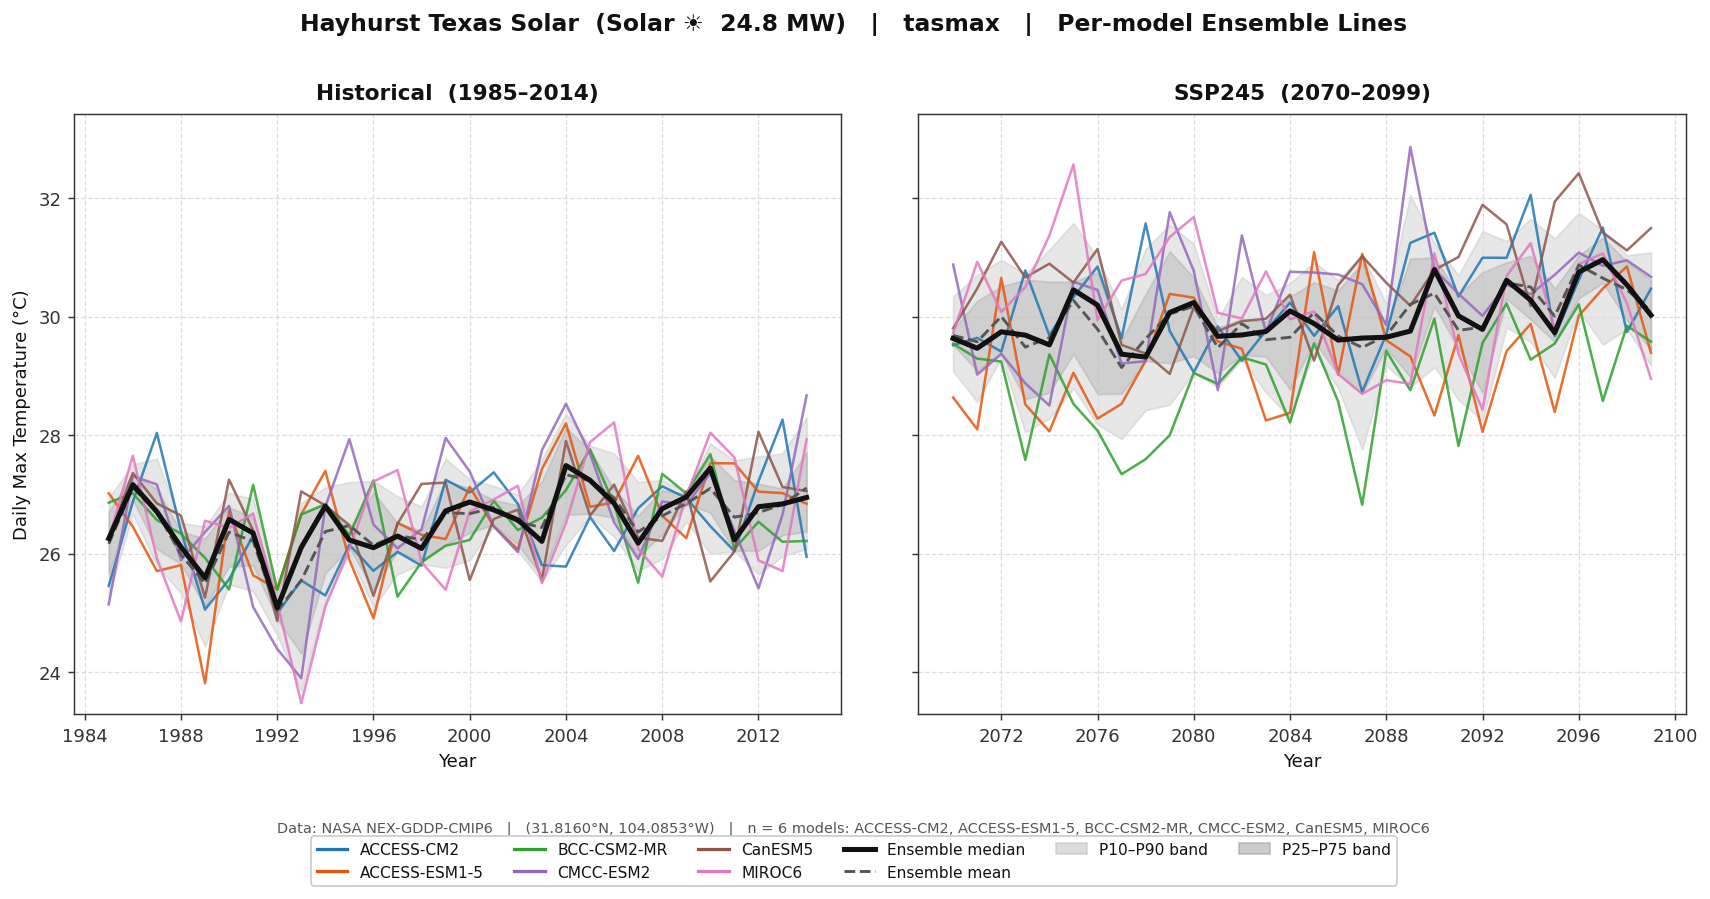

  Saved → Maverick_Wind_tasmax_spaghetti.png


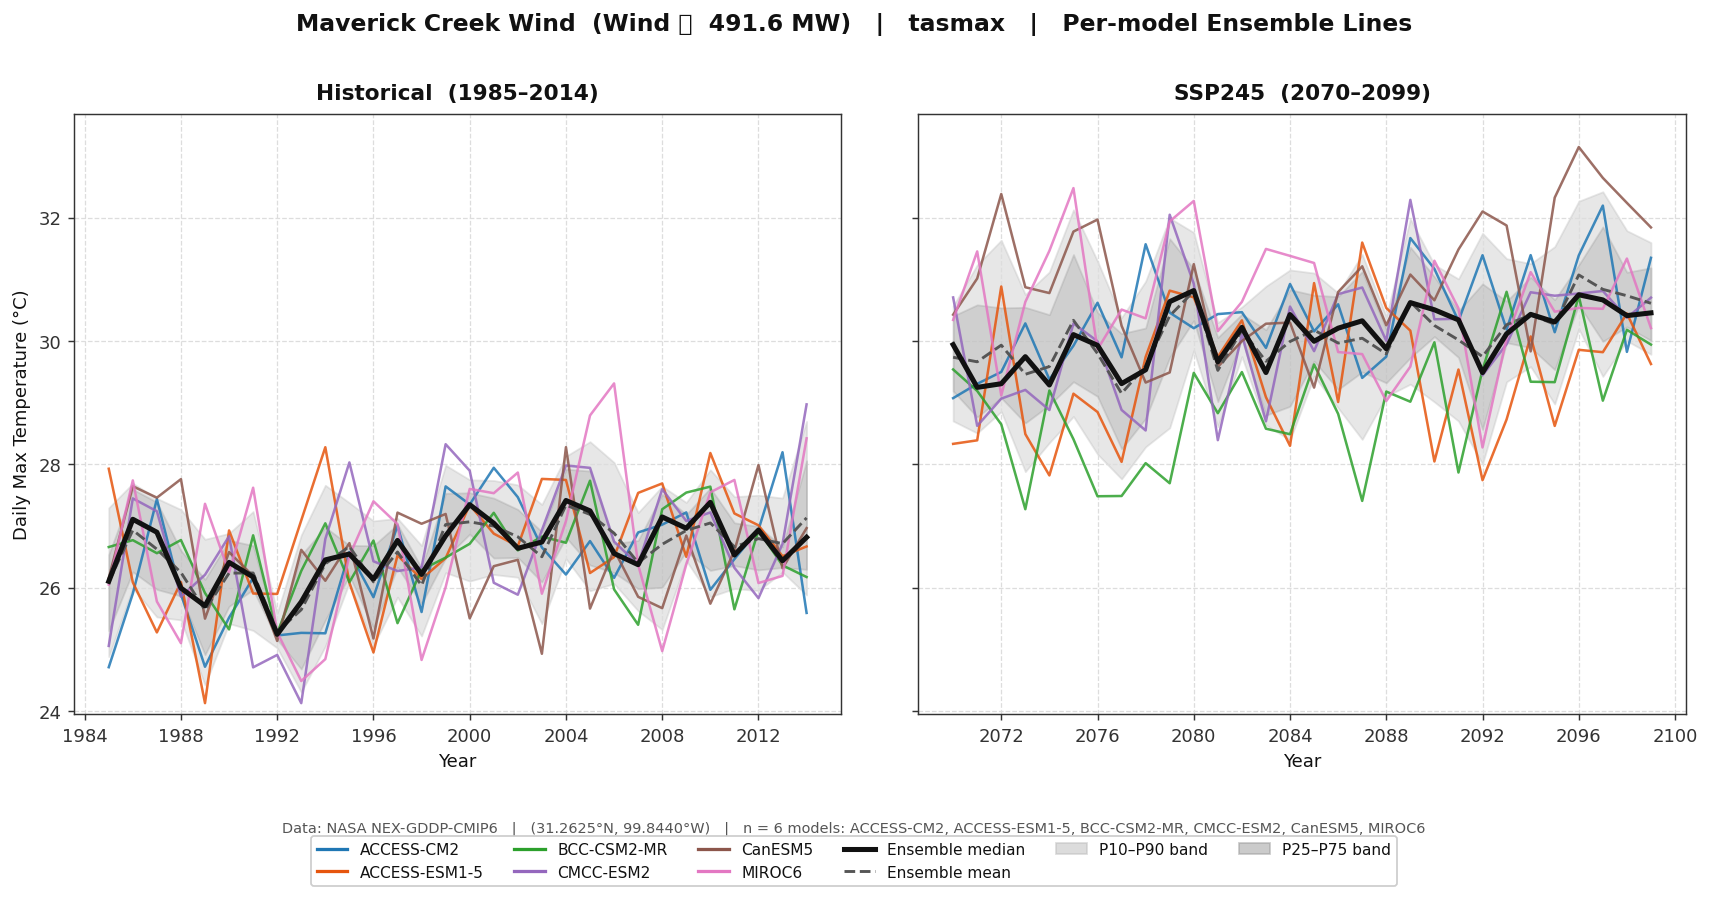

In [12]:
def plot_spaghetti(R, baseline_scen, future_scen,
                   baseline_years, future_years):
    """
    One figure per site showing every model as its own coloured line
    for both baseline and future scenarios.
    Layout: 2 rows
      Top    : full time series both scenarios side by side
      Bottom : baseline (left) and future (right) separated for clarity
    """
    site     = R["site"]
    variable = R["variable"]
    ylabel   = R["ylabel"]
    common   = R["common"]
    base_df  = R["base_df"]   # index=year, columns=models
    fut_df   = R["fut_df"]
    base_stats = R["base_stats"]
    fut_stats  = R["fut_stats"]

    fig, axes = plt.subplots(
        1, 2, figsize=(16, 6),
        gridspec_kw={"wspace": 0.10}
    )
    fig.patch.set_facecolor("white")

    titles = [
        f"Historical  ({baseline_years[0]}–{baseline_years[1]})",
        f"{future_scen.upper()}  ({future_years[0]}–{future_years[1]})",
    ]
    data_pairs = [
        (base_df, base_stats),
        (fut_df,  fut_stats),
    ]

    y_all = pd.concat([base_df, fut_df]).values.flatten()
    y_all = y_all[~np.isnan(y_all)]
    y_min = y_all.min() - 0.02 * np.ptp(y_all)
    y_max = y_all.max() + 0.06 * np.ptp(y_all)

    legend_handles = []

    for ax, title, (df, stats) in zip(axes, titles, data_pairs):
        ax.set_facecolor("white")

        # ── P10/P90 shaded band ───────────────────────────────────────────
        ax.fill_between(stats.index, stats["p10"], stats["p90"],
                        color="#bbbbbb", alpha=0.35, zorder=1,
                        label="P10–P90 band")
        ax.fill_between(stats.index, stats["p25"], stats["p75"],
                        color="#999999", alpha=0.30, zorder=2,
                        label="P25–P75 band")

        # ── Individual model lines ────────────────────────────────────────
        for model in common:
            color = get_model_color(model, common)
            ax.plot(df.index, df[model],
                    color=color, lw=1.4, alpha=0.85,
                    zorder=3, label=model)

        # ── Ensemble median (bold black) ──────────────────────────────────
        ax.plot(stats.index, stats["p50"],
                color="#111111", lw=2.8, zorder=6,
                label="Ensemble median")

        # ── Ensemble mean (dark dashed) ───────────────────────────────────
        ax.plot(stats.index, stats["mean"],
                color="#555555", lw=1.6, ls="--", zorder=5,
                label="Ensemble mean")

        ax.set_title(title, fontsize=12, fontweight="bold",
                     color="#111111", pad=8)
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylim(y_min, y_max)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))

    # Shared y-label on left axis only
    axes[0].set_ylabel(ylabel, fontsize=10)
    axes[1].set_yticklabels([])

    # ── Unified legend below both panels ─────────────────────────────────────
    # Model colour patches
    model_handles = [
        mlines.Line2D([], [], color=get_model_color(m, common),
                      lw=1.8, label=m)
        for m in common
    ]
    # Ensemble handles
    ens_handles = [
        mlines.Line2D([], [], color="#111111", lw=2.8,
                      label="Ensemble median"),
        mlines.Line2D([], [], color="#555555", lw=1.6, ls="--",
                      label="Ensemble mean"),
        mpatches.Patch(color="#bbbbbb", alpha=0.5,
                       label="P10–P90 band"),
        mpatches.Patch(color="#999999", alpha=0.5,
                       label="P25–P75 band"),
    ]
    all_handles = model_handles + ens_handles

    fig.legend(
        handles=all_handles,
        loc="lower center",
        ncol=min(len(all_handles), 6),
        fontsize=8.5,
        framealpha=0.95,
        edgecolor="#cccccc",
        bbox_to_anchor=(0.5, -0.12),
    )

    # ── Site info header ──────────────────────────────────────────────────────
    fig.suptitle(
        f"{site['name']}  ({site['asset_type']}  {site['capacity_mw']} MW)   "
        f"|   {variable}   |   Per-model Ensemble Lines",
        fontsize=13, fontweight="bold", color="#111111", y=1.01
    )
    fig.text(
        0.5, -0.04,
        f"Data: NASA NEX-GDDP-CMIP6   |   "
        f"({site['lat']:.4f}°N, {abs(site['lon']):.4f}°W)   |   "
        f"n = {len(common)} models: {', '.join(common)}",
        ha="center", fontsize=8, color="#555555"
    )

    plt.tight_layout()
    out = f"{site['short']}_{variable}_spaghetti.png"
    plt.savefig(out, dpi=150, bbox_inches="tight",
                facecolor="white")
    print(f"  Saved → {out}")
    plt.show()

for key, R in RESULTS.items():
    plot_spaghetti(R, BASELINE_SCENARIO, FUTURE_SCENARIO,
                   BASELINE_YEARS, FUTURE_YEARS)


### 8.4 P10/P90 envelope

In [13]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

def plot_envelope_white(R, baseline_scen, future_scen,
                        baseline_years, future_years):
    site       = R["site"]
    variable   = R["variable"]
    ylabel     = R["ylabel"]
    common     = R["common"]
    base_stats = R["base_stats"]
    fut_stats  = R["fut_stats"]
    base_df    = R["base_df"]
    fut_df     = R["fut_df"]

    base_color = SCEN_STYLE.get(baseline_scen, {}).get("color", "#444444")
    fut_color  = SCEN_STYLE.get(future_scen,   {}).get("color", "#c51b8a")

    bv = base_df.values.flatten(); bv = bv[~np.isnan(bv)]
    fv = fut_df.values.flatten();  fv = fv[~np.isnan(fv)]

    stats_data = {
        "Mean":        (np.mean(bv),                            np.mean(fv)),
        "P10":         (np.percentile(bv, 10),                  np.percentile(fv, 10)),
        "P25":         (np.percentile(bv, 25),                  np.percentile(fv, 25)),
        "Median":      (np.median(bv),                          np.median(fv)),
        "P75":         (np.percentile(bv, 75),                  np.percentile(fv, 75)),
        "P90":         (np.percentile(bv, 90),                  np.percentile(fv, 90)),
        "Spread":      (np.percentile(bv,90)-np.percentile(bv,10),
                        np.percentile(fv,90)-np.percentile(fv,10)),
        "Std Dev":     (np.std(bv),                             np.std(fv)),
    }
    delta_median = np.median(fv) - np.median(bv)
    delta_pct    = 100 * delta_median / abs(np.median(bv))

    fig, (ax, ax_tbl) = plt.subplots(
        1, 2, figsize=(16, 6),
        gridspec_kw={"width_ratios": [2.8, 1], "wspace": 0.08}
    )
    fig.patch.set_facecolor("white")

    # Baseline band
    ax.fill_between(base_stats.index, base_stats["p10"], base_stats["p90"],
                    alpha=0.13, color=base_color, zorder=1)
    ax.fill_between(base_stats.index, base_stats["p25"], base_stats["p75"],
                    alpha=0.22, color=base_color, zorder=2,
                    label="{} P25-P75".format(baseline_scen))
    ax.plot(base_stats.index, base_stats["p10"],
            color=base_color, lw=0.9, ls=":", alpha=0.7, zorder=3)
    ax.plot(base_stats.index, base_stats["p90"],
            color=base_color, lw=0.9, ls=":", alpha=0.7, zorder=3,
            label="{} P10/P90".format(baseline_scen))
    ax.plot(base_stats.index, base_stats["p50"],
            color=base_color, lw=2.8, zorder=5,
            label="{} Median".format(baseline_scen))
    ax.plot(base_stats.index, base_stats["mean"],
            color=base_color, lw=1.5, ls="--", alpha=0.80, zorder=4,
            label="{} Mean".format(baseline_scen))

    # Future band
    ax.fill_between(fut_stats.index, fut_stats["p10"], fut_stats["p90"],
                    alpha=0.13, color=fut_color, zorder=1)
    ax.fill_between(fut_stats.index, fut_stats["p25"], fut_stats["p75"],
                    alpha=0.22, color=fut_color, zorder=2,
                    label="{} P25-P75".format(future_scen))
    ax.plot(fut_stats.index, fut_stats["p10"],
            color=fut_color, lw=0.9, ls=":", alpha=0.7, zorder=3)
    ax.plot(fut_stats.index, fut_stats["p90"],
            color=fut_color, lw=0.9, ls=":", alpha=0.7, zorder=3,
            label="{} P10/P90".format(future_scen))
    ax.plot(fut_stats.index, fut_stats["p50"],
            color=fut_color, lw=2.8, zorder=5,
            label="{} Median".format(future_scen))
    ax.plot(fut_stats.index, fut_stats["mean"],
            color=fut_color, lw=1.5, ls="--", alpha=0.80, zorder=4,
            label="{} Mean".format(future_scen))

    # Annotate P10 / Median / P90 at end of future period
    last_yr = fut_stats.index[-1]
    for pct, key, va in [(10, "p10", "top"), (50, "p50", "center"), (90, "p90", "bottom")]:
        b_val = base_stats[key].iloc[-1]
        f_val = fut_stats[key].iloc[-1]
        delta = f_val - b_val
        label = "P{}: {:.2f}\n(D{:+.2f})".format(pct, f_val, delta)
        ax.annotate(
            label,
            xy=(last_yr, f_val),
            xytext=(last_yr + 1.5, f_val),
            fontsize=7.5, color=fut_color, va=va,
            arrowprops=dict(arrowstyle="-", color=fut_color, lw=0.8, alpha=0.6),
        )

    ax.set_title("P10/P90 Envelope  -  {} vs {}".format(baseline_scen, future_scen),
                 fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.legend(loc="upper left", fontsize=8, ncol=2,
              framealpha=0.92, edgecolor="#cccccc")

    # Stats table
    ax_tbl.set_facecolor("white")
    ax_tbl.axis("off")

    col_labels = [baseline_scen, future_scen, "Delta"]
    row_labels  = list(stats_data.keys())
    cell_text   = []
    cell_colors = []

    for stat, (bval, fval) in stats_data.items():
        delta  = fval - bval
        sign   = "+" if delta > 0 else ""
        row    = ["{:.3f}".format(bval), "{:.3f}".format(fval),
                  "{}{:.3f}".format(sign, delta)]
        cell_text.append(row)
        if stat == "Spread":
            d_color = "white"
        elif delta > 0:
            d_color = "#e8f5e9"
        elif delta < 0:
            d_color = "#ffebee"
        else:
            d_color = "white"
        cell_colors.append(["white", "white", d_color])

    tbl = ax_tbl.table(
        cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
        cellColours=cell_colors, cellLoc="center", rowLoc="right", loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1.0, 1.65)
    for (row, col), cell_obj in tbl.get_celld().items():
        cell_obj.set_edgecolor("#dddddd")
        if row == 0:
            cell_obj.set_facecolor("#f0f0f0")
            cell_obj.set_text_props(fontweight="bold", color="#111111")
        if col == -1:
            cell_obj.set_facecolor("#f8f8f8")
            cell_obj.set_text_props(fontweight="bold", color="#333333")
            cell_obj.set_edgecolor("#dddddd")

    ax_tbl.set_title("Statistics\n(pooled all models x years)",
                     fontsize=9, fontweight="bold", pad=6, color="#333333")

    # Delta summary box — NO f-string with newline
    summary = "Delta Median = {:+.3f}  ({:+.1f}%)".format(delta_median, delta_pct)
    ax_tbl.text(
        0.5, 0.02, summary,
        transform=ax_tbl.transAxes,
        ha="center", va="bottom", fontsize=9, fontweight="bold",
        color=fut_color,
        bbox=dict(facecolor="#fff9f9", edgecolor=fut_color,
                  alpha=0.9, pad=4, boxstyle="round,pad=0.4")
    )

    fig.suptitle(
        "{} ({} {} MW) | {}".format(
            site["name"], site["asset_type"], site["capacity_mw"], variable),
        fontsize=13, fontweight="bold", color="#111111", y=1.01
    )
    fig.text(
        0.5, -0.03,
        "NASA NEX-GDDP-CMIP6  |  ({:.4f}N, {:.4f}W)  |  n={} models: {}".format(
            site["lat"], abs(site["lon"]), len(common), ", ".join(common)),
        ha="center", fontsize=8, color="#555555"
    )

    plt.tight_layout()
    out = "{}_{}_envelope_white.png".format(site["short"], variable)
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print("  Saved -> {}".format(out))
    plt.show()

print("plot_envelope_white redefined ✅")

plot_envelope_white redefined ✅


  Saved → Hayhurst_Solar_tasmax_envelope_white.png


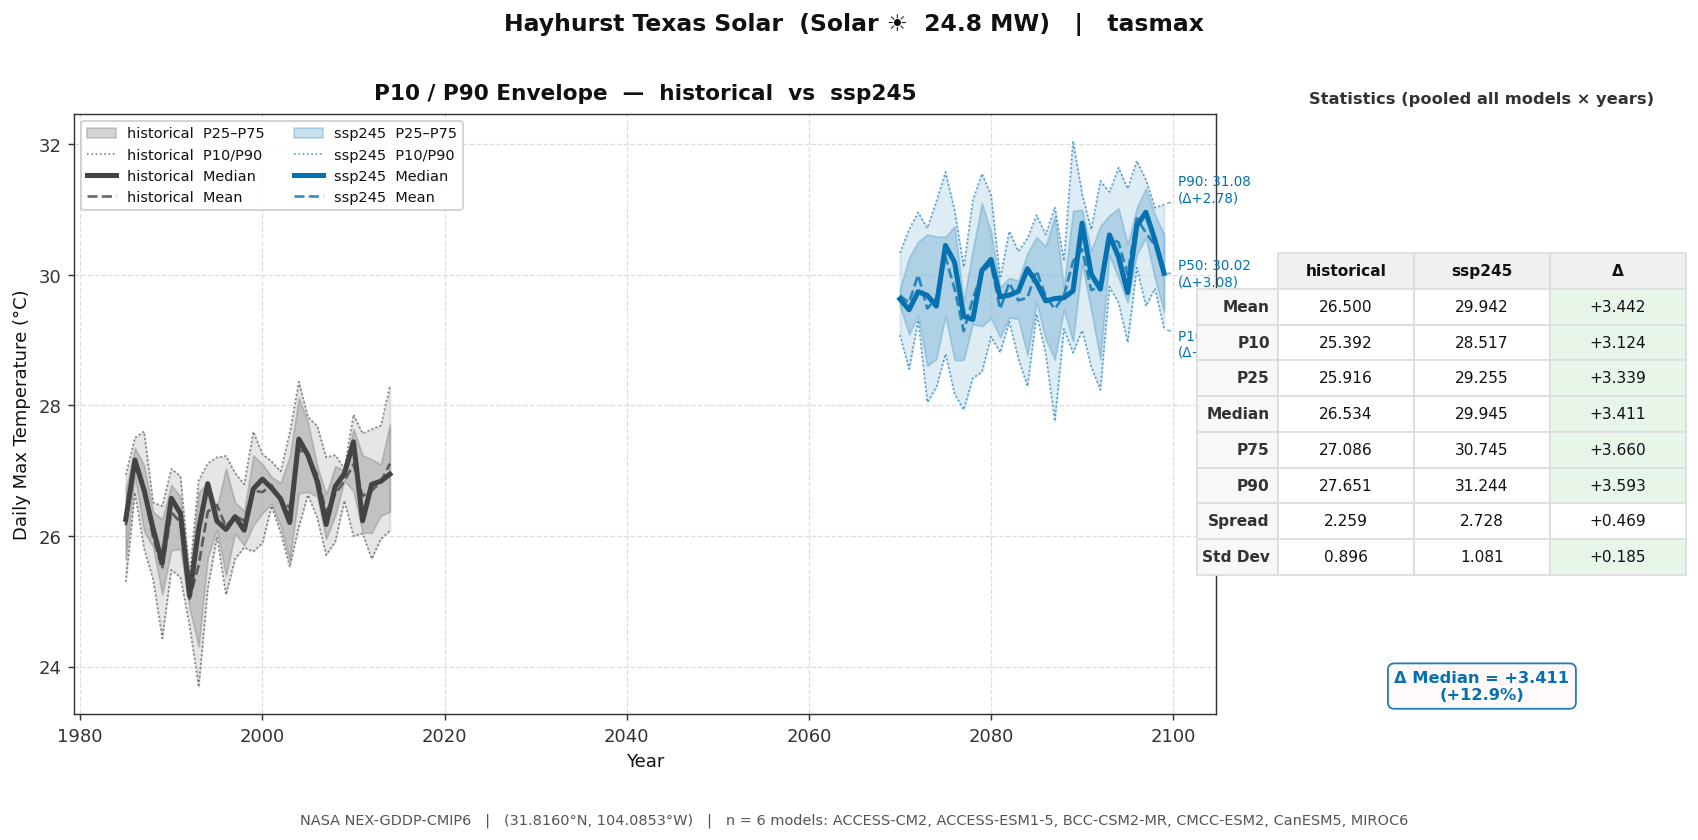

  Saved → Maverick_Wind_tasmax_envelope_white.png


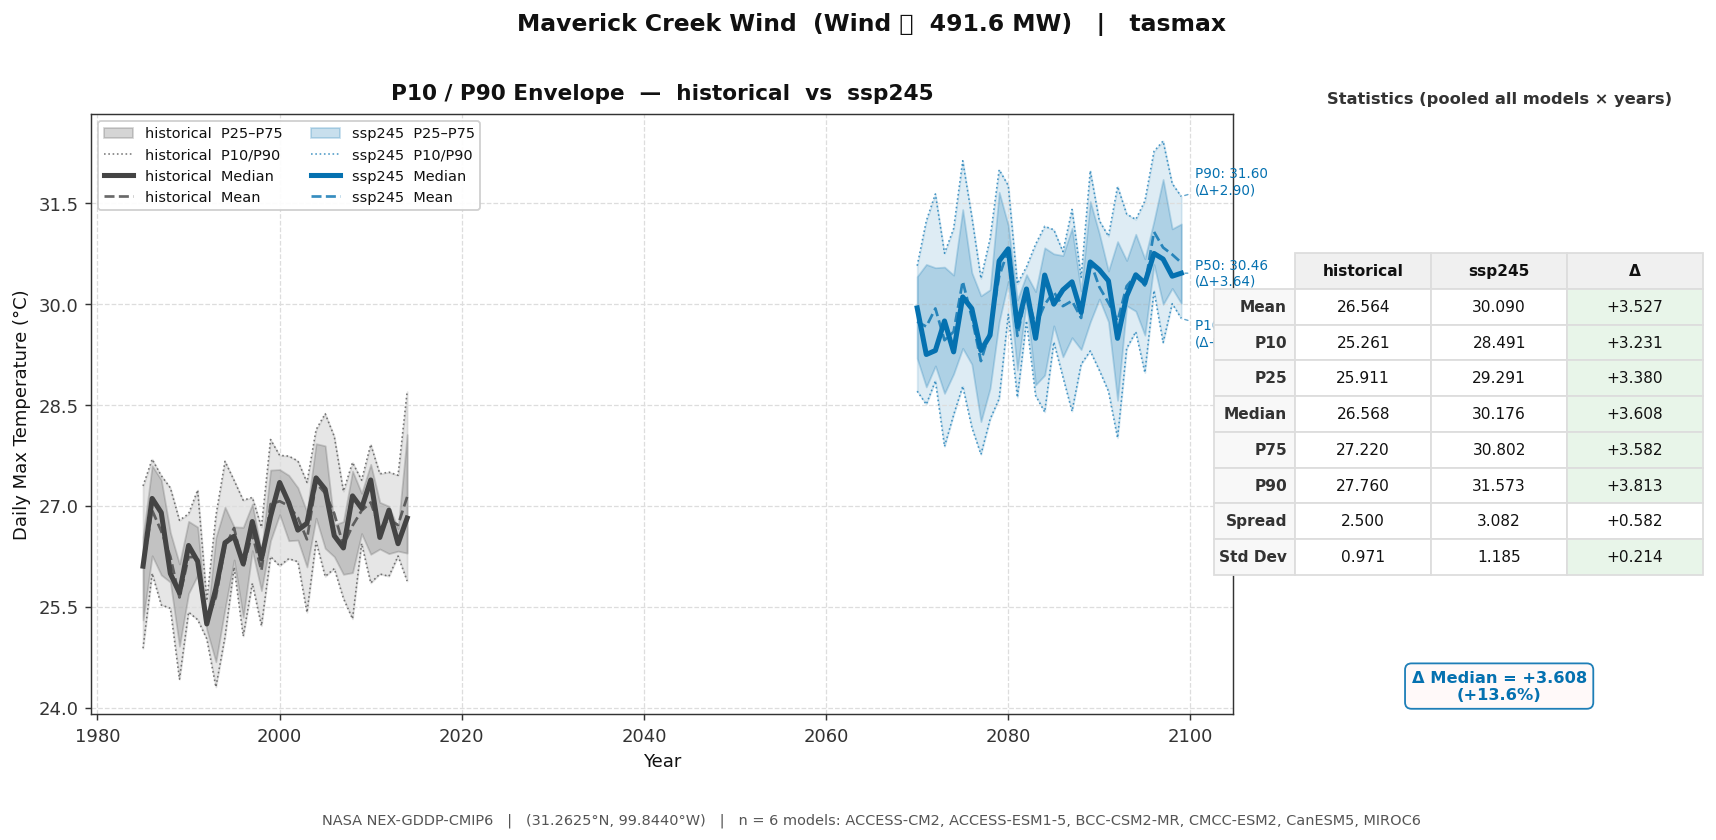

In [14]:
def plot_envelope_white(R, baseline_scen, future_scen,
                        baseline_years, future_years):
    """
    Clean P10/P90 envelope on white background.
    Single panel: baseline and future overlaid.
    Right panel: summary statistics table.
    """
    site       = R["site"]
    variable   = R["variable"]
    ylabel     = R["ylabel"]
    common     = R["common"]
    base_stats = R["base_stats"]
    fut_stats  = R["fut_stats"]
    base_df    = R["base_df"]
    fut_df     = R["fut_df"]

    base_style = SCEN_STYLE.get(baseline_scen,
                                 dict(color="#444444", ls="-", lw=2.5))
    fut_style  = SCEN_STYLE.get(future_scen,
                                 dict(color="#c51b8a", ls="-", lw=2.5))
    base_color = base_style["color"]
    fut_color  = fut_style["color"]

    # ── Pooled stats for annotation ───────────────────────────────────────────
    bv = base_df.values.flatten(); bv = bv[~np.isnan(bv)]
    fv = fut_df.values.flatten();  fv = fv[~np.isnan(fv)]

    stats_data = {
        "Mean":        (np.mean(bv),               np.mean(fv)),
        "P10":         (np.percentile(bv, 10),      np.percentile(fv, 10)),
        "P25":         (np.percentile(bv, 25),      np.percentile(fv, 25)),
        "Median":      (np.median(bv),              np.median(fv)),
        "P75":         (np.percentile(bv, 75),      np.percentile(fv, 75)),
        "P90":         (np.percentile(bv, 90),      np.percentile(fv, 90)),
        "Spread":      (np.percentile(bv,90)-np.percentile(bv,10),
                        np.percentile(fv,90)-np.percentile(fv,10)),
        "Std Dev":     (np.std(bv),                 np.std(fv)),
    }
    delta_median = np.median(fv) - np.median(bv)
    delta_pct    = 100 * delta_median / abs(np.median(bv))

    # ── Figure layout: main envelope (left, wide) + stats table (right) ───────
    fig, (ax, ax_tbl) = plt.subplots(
        1, 2, figsize=(16, 6),
        gridspec_kw={"width_ratios": [2.8, 1], "wspace": 0.08}
    )
    fig.patch.set_facecolor("white")

    # ── Baseline band ─────────────────────────────────────────────────────────
    ax.fill_between(base_stats.index,
                    base_stats["p10"], base_stats["p90"],
                    alpha=0.13, color=base_color, zorder=1)
    ax.fill_between(base_stats.index,
                    base_stats["p25"], base_stats["p75"],
                    alpha=0.22, color=base_color, zorder=2,
                    label=f"{baseline_scen}  P25–P75")
    ax.plot(base_stats.index, base_stats["p10"],
            color=base_color, lw=0.9, ls=":", alpha=0.7, zorder=3)
    ax.plot(base_stats.index, base_stats["p90"],
            color=base_color, lw=0.9, ls=":", alpha=0.7, zorder=3,
            label=f"{baseline_scen}  P10/P90")
    ax.plot(base_stats.index, base_stats["p50"],
            color=base_color, lw=2.8, zorder=5,
            label=f"{baseline_scen}  Median")
    ax.plot(base_stats.index, base_stats["mean"],
            color=base_color, lw=1.5, ls="--", alpha=0.80, zorder=4,
            label=f"{baseline_scen}  Mean")

    # ── Future band ───────────────────────────────────────────────────────────
    ax.fill_between(fut_stats.index,
                    fut_stats["p10"], fut_stats["p90"],
                    alpha=0.13, color=fut_color, zorder=1)
    ax.fill_between(fut_stats.index,
                    fut_stats["p25"], fut_stats["p75"],
                    alpha=0.22, color=fut_color, zorder=2,
                    label=f"{future_scen}  P25–P75")
    ax.plot(fut_stats.index, fut_stats["p10"],
            color=fut_color, lw=0.9, ls=":", alpha=0.7, zorder=3)
    ax.plot(fut_stats.index, fut_stats["p90"],
            color=fut_color, lw=0.9, ls=":", alpha=0.7, zorder=3,
            label=f"{future_scen}  P10/P90")
    ax.plot(fut_stats.index, fut_stats["p50"],
            color=fut_color, lw=2.8, zorder=5,
            label=f"{future_scen}  Median")
    ax.plot(fut_stats.index, fut_stats["mean"],
            color=fut_color, lw=1.5, ls="--", alpha=0.80, zorder=4,
            label=f"{future_scen}  Mean")

    # ── Annotate Δ at end of future period ────────────────────────────────────
    last_yr = fut_stats.index[-1]
    for pct, key, va in [(10, "p10", "top"), (50, "p50", "center"),
                          (90, "p90", "bottom")]:
        b_val = base_stats[key].iloc[-1]   # last value of baseline
        f_val = fut_stats[key].iloc[-1]    # last value of future
        delta = f_val - b_val
        ax.annotate(
            "P{}: {:.2f}\n(\u0394{:+.2f})".format(pct, f_val, delta),
            xy=(last_yr, f_val),
            xytext=(last_yr + 1.5, f_val),
            fontsize=7.5, color=fut_color, va=va,
            arrowprops=dict(arrowstyle="-", color=fut_color,
                            lw=0.8, alpha=0.6),
        )

    ax.set_title(
        f"P10 / P90 Envelope  —  {baseline_scen}  vs  {future_scen}",
        fontsize=12, fontweight="bold", pad=8
    )
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.legend(
        loc="upper left", fontsize=8, ncol=2,
        framealpha=0.92, edgecolor="#cccccc"
    )

    # ── Stats table panel ─────────────────────────────────────────────────────
    ax_tbl.set_facecolor("white")
    ax_tbl.axis("off")

    col_labels = [baseline_scen, future_scen, "Δ"]
    row_labels  = list(stats_data.keys())
    cell_text   = []
    cell_colors = []

    for stat, (bval, fval) in stats_data.items():
        delta = fval - bval
        sign  = "+" if delta > 0 else ""
        row   = [f"{bval:.3f}", f"{fval:.3f}", f"{sign}{delta:.3f}"]
        cell_text.append(row)

        # Color the delta cell: green=increase, red=decrease, white=neutral
        if stat == "Spread":
            d_color = "white"
        elif delta > 0:
            d_color = "#e8f5e9"
        elif delta < 0:
            d_color = "#ffebee"
        else:
            d_color = "white"

        cell_colors.append(["white", "white", d_color])

    tbl = ax_tbl.table(
        cellText   = cell_text,
        rowLabels  = row_labels,
        colLabels  = col_labels,
        cellColours= cell_colors,
        cellLoc    = "center",
        rowLoc     = "right",
        loc        = "center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1.0, 1.65)

    # Style header row and row labels
    for (row, col), cell_obj in tbl.get_celld().items():
        cell_obj.set_edgecolor("#dddddd")
        if row == 0:   # header
            cell_obj.set_facecolor("#f0f0f0")
            cell_obj.set_text_props(fontweight="bold", color="#111111")
        if col == -1:  # row labels
            cell_obj.set_facecolor("#f8f8f8")
            cell_obj.set_text_props(fontweight="bold", color="#333333")
            cell_obj.set_edgecolor("#dddddd")

    ax_tbl.set_title("Statistics (pooled all models × years)",
                     fontsize=9, fontweight="bold", pad=6, color="#333333")

    # Δ median summary below table
    ax_tbl.text(
        0.5, 0.02,
        "Δ Median = {:+.3f}\n({:+.1f}%)".format(delta_median, delta_pct),
        transform=ax_tbl.transAxes,
        ha="center", va="bottom", fontsize=9, fontweight="bold",
        color=fut_color,
        bbox=dict(facecolor="#fff9f9", edgecolor=fut_color,
                  alpha=0.9, pad=4, boxstyle="round,pad=0.4")
    )

    # ── Site metadata ─────────────────────────────────────────────────────────
    fig.suptitle(
        f"{site['name']}  ({site['asset_type']}  {site['capacity_mw']} MW)   "
        f"|   {variable}",
        fontsize=13, fontweight="bold", color="#111111", y=1.01
    )
    fig.text(
        0.5, -0.03,
        f"NASA NEX-GDDP-CMIP6   |   "
        f"({site['lat']:.4f}°N, {abs(site['lon']):.4f}°W)   |   "
        f"n = {len(common)} models: {', '.join(common)}",
        ha="center", fontsize=8, color="#555555"
    )

    plt.tight_layout()
    out = f"{site['short']}_{variable}_envelope_white.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  Saved → {out}")
    plt.show()

for key, R in RESULTS.items():
    plot_envelope_white(R, BASELINE_SCENARIO, FUTURE_SCENARIO,
                        BASELINE_YEARS, FUTURE_YEARS)